In [1]:
## Simple chatbot using LangGraph

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


# Simple Chatbot with LangGraph

This notebook demonstrates how to build a simple chatbot using LangGraph that maintains conversation memory.

## Key Concepts:

1. **State Management**: Using TypedDict with `add_messages` reducer to accumulate conversation history
2. **Graph Structure**: Simple linear graph with one node that processes messages
3. **Memory**: Maintaining conversation history by passing all previous messages
4. **LLM Integration**: Using Groq's Gemma model for natural language responses

## Features:

- ✅ Basic conversation capability
- ✅ Memory retention within a session
- ✅ Proper message handling with LangChain
- ✅ Helper class for easier conversation management

In [2]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_API_KEY")
os.environ["OPENAI_ENDPOINT"] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ["OPENAI_API_VERSION"] = "2024-12-01-preview"
os.environ["OPENAI_DEPLOYMENT_NAME"] = "gpt-4o-mini"
os.environ["OPENAI_MODEL"] = "gpt-4o-mini"

open_api_key = os.getenv("AZURE_OPENAI_API_KEY")
if os.getenv("AZURE_OPENAI_API_KEY"):
    print(f"Azure Open API Key loaded: {open_api_key[:10]}...{open_api_key[-4:]}")
    print(f"Model: {os.getenv('OPENAI_MODEL')}")
    os.environ["OPENAI_API_KEY"] = open_api_key
else:
    print("Azure API Key not found in environment variables")
    print("Available environment variables with 'Azure':", [k for k in os.environ.keys() if 'Azure' in k.upper()])

groq_api_key = os.getenv("GROQ_API_KEY")
if os.getenv("GROQ_API_KEY"):
    print(f"GROQ API Key loaded: {groq_api_key[:10]}...{groq_api_key[-4:]}")
    os.environ["GROQ_API_KEY"] = groq_api_key
else:
    print("GROQ API Key not found in environment variables")
    print("Available environment variables with 'GROQ':", [k for k in os.environ.keys() if 'GROQ' in k.upper()])


Azure Open API Key loaded: 1Sttw3VbMy...EzVq
Model: gpt-4o-mini
GROQ API Key loaded: gsk_kJ3nEw...OOCG


In [13]:
from langchain_openai import AzureChatOpenAI
from langchain.schema import HumanMessage, SystemMessage

# Create Azure ChatOpenAI instance
llm_openai = AzureChatOpenAI(
    azure_deployment=os.getenv("OPENAI_DEPLOYMENT_NAME"),  # your deployment name
    api_version=os.getenv("OPENAI_API_VERSION"),           # API version
    azure_endpoint=os.getenv("OPENAI_ENDPOINT"),           # your endpoint URL
    api_key=os.getenv("OPENAI_API_KEY"),                   # your API key
    temperature=0.7,                                        # creativity level
    max_tokens=1000                                         # response length limit
)

print(f"Created Azure ChatOpenAI: {llm_openai}")

Created Azure ChatOpenAI: client=<openai.resources.chat.completions.completions.Completions object at 0x72e4ee571400> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x72e4ee43ac30> root_client=<openai.lib.azure.AzureOpenAI object at 0x72e4eee91430> root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x72e4ee632780> temperature=0.7 model_kwargs={} openai_api_key=SecretStr('**********') max_tokens=1000 disabled_params={'parallel_tool_calls': None} azure_endpoint='https://zama-roadmap-to-aiml.openai.azure.com/' deployment_name='gpt-4o-mini' openai_api_version='2024-12-01-preview' openai_api_type='azure'


In [4]:
from langchain_groq import ChatGroq

# Initialize the ChatGroq model
llm_groq = ChatGroq(
    model="gemma2-9b-it",
    api_key=os.environ.get("GROQ_API_KEY")
)
print(f"Created Groq: {llm_groq}")

Created Groq: client=<groq.resources.chat.completions.Completions object at 0x72e57c45f8c0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72e57c3bae70> model_name='gemma2-9b-it' model_kwargs={} groq_api_key=SecretStr('**********')


In [5]:
# Create node

def superbot(state: State):
    messages = state['messages']
    response = llm_groq.invoke(messages)
    return {"messages": [response]}

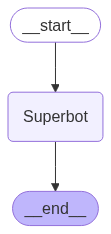

In [6]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Use the State class that was defined with messages field (from cell 2)
# Make sure we're using the correct State class
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph = StateGraph(State)

graph.add_node("Superbot", superbot)

graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile()

# View
display(Image(graph_builder.get_graph().draw_mermaid_png()))



In [7]:
# Invoke the graph
from langchain.schema import HumanMessage

graph_builder.invoke({'messages': [HumanMessage(content="My name is Zama, I like cricket")]})

{'messages': [HumanMessage(content='My name is Zama, I like cricket', additional_kwargs={}, response_metadata={}, id='f726a0d6-d4c2-42fa-be35-ee3d35e59eea'),
  AIMessage(content="That's great, Zama! Cricket is a wonderful sport. \n\nDo you have a favourite team or player?  🏏 \n\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 18, 'total_tokens': 50, 'completion_time': 0.058181818, 'prompt_time': 0.001918478, 'queue_time': 0.244130872, 'total_time': 0.060100296}, 'model_name': 'gemma2-9b-it', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--7b008ddf-78fe-4524-bc34-b0bb9e1685d6-0', usage_metadata={'input_tokens': 18, 'output_tokens': 32, 'total_tokens': 50})]}

In [9]:
# Test conversation memory by building conversation history
from langchain.schema import HumanMessage

# Start a conversation and maintain the history
conversation_history = []

# First message - introduce yourself
result1 = graph_builder.invoke({'messages': [HumanMessage(content="My name is Zama, I like cricket")]})
conversation_history.extend(result1['messages'])

print("=== First interaction ===")
for msg in result1['messages']:
    print(f"{type(msg).__name__}: {msg.content}")

print("\n=== Second interaction (with history) ===")
# Second message - ask about name, but include previous conversation
conversation_history.append(HumanMessage(content="What is my name?"))
result2 = graph_builder.invoke({'messages': conversation_history})

for msg in result2['messages']:
    print(f"{type(msg).__name__}: {msg.content}")

=== First interaction ===
HumanMessage: My name is Zama, I like cricket
AIMessage: That's great, Zama! Cricket is a wonderful sport. 🏏 

Do you have a favorite team or player?  😊



=== Second interaction (with history) ===
HumanMessage: My name is Zama, I like cricket
AIMessage: That's great, Zama! Cricket is a wonderful sport. 🏏 

Do you have a favorite team or player?  😊


HumanMessage: What is my name?
AIMessage: Your name is Zama!  😊  

We established that at the beginning of our conversation.  

Is there anything else you'd like to chat about?

HumanMessage: My name is Zama, I like cricket
AIMessage: That's great, Zama! Cricket is a wonderful sport. 🏏 

Do you have a favorite team or player?  😊


HumanMessage: What is my name?
AIMessage: Your name is Zama!  😊  

We established that at the beginning of our conversation.  

Is there anything else you'd like to chat about?



In [10]:
# Comparison: Without Memory vs With Memory
print("=== WITHOUT MEMORY (each call is independent) ===")
# This is what happens when we don't maintain history
result_no_memory = graph_builder.invoke({'messages': [HumanMessage(content="What is my name?")]})
for msg in result_no_memory['messages']:
    print(f"{type(msg).__name__}: {msg.content}")

print("\n=== WITH MEMORY (maintaining conversation history) ===")
# Start fresh conversation
conversation = []

# First introduce yourself
intro_result = graph_builder.invoke({'messages': [HumanMessage(content="My name is Zama, I like cricket")]})
conversation.extend(intro_result['messages'])

print("After introduction:")
for msg in intro_result['messages']:
    print(f"{type(msg).__name__}: {msg.content}")

# Now ask about name with conversation history
conversation.append(HumanMessage(content="What is my name?"))
name_result = graph_builder.invoke({'messages': conversation})

print("\nAfter asking for name (with history):")
for msg in name_result['messages'][-1:]:  # Only show the new response
    print(f"{type(msg).__name__}: {msg.content}")

=== WITHOUT MEMORY (each call is independent) ===
HumanMessage: What is my name?
AIMessage: As an AI, I have no access to your personal information, including your name.

Can you tell me your name? 😊


=== WITH MEMORY (maintaining conversation history) ===
After introduction:
HumanMessage: My name is Zama, I like cricket
AIMessage: Hello Zama!

It's great to meet you. Cricket is a fantastic sport! 🏏

Do you have a favourite team or player? 😊



After asking for name (with history):
AIMessage: Your name is Zama!  😊  

I remember that you told me.  What can I do for you today?



In [11]:
# Helper function for easier conversation handling
class ChatbotSession:
    def __init__(self, graph_builder):
        self.graph_builder = graph_builder
        self.conversation_history = []
    
    def chat(self, message: str):
        """Send a message and get response while maintaining history"""
        # Add user message to history
        human_msg = HumanMessage(content=message)
        self.conversation_history.append(human_msg)
        
        # Get response from chatbot
        result = self.graph_builder.invoke({'messages': self.conversation_history})
        
        # Update conversation history with all messages
        self.conversation_history = result['messages']
        
        # Return just the latest AI response
        return result['messages'][-1].content
    
    def get_history(self):
        """Get the full conversation history"""
        return self.conversation_history
    
    def clear_history(self):
        """Clear conversation history"""
        self.conversation_history = []

# Create a session
session = ChatbotSession(graph_builder)

# Test the session
print("=== Testing ChatbotSession ===")
response1 = session.chat("Hi, my name is Zama and I love playing cricket")
print(f"Bot: {response1}")

response2 = session.chat("What is my name?")
print(f"Bot: {response2}")

response3 = session.chat("What sport do I like?")
print(f"Bot: {response3}")

print(f"\nConversation has {len(session.get_history())} messages")

=== Testing ChatbotSession ===
Bot: Hi Zama, it's great to meet you! That's awesome that you love playing cricket.  

Is there a particular team you support? Or a favorite player? 🏏  I'd love to hear more about why you enjoy the game. 😊  


Bot: Your name is Zama. 😊  

I remember that from our first conversation!  





Bot: You like playing cricket! 🏏  




Conversation has 6 messages


In [12]:
# Test edge cases and multiple conversation flows
print("=== Testing Multiple Conversations ===")

# Test clearing history
session.clear_history()
print(f"After clearing: {len(session.get_history())} messages")

# Test new conversation
response = session.chat("What's my favorite color?")
print(f"Bot (new session): {response}")

# Test that memory doesn't carry over
response = session.chat("I told you my name earlier, what was it?")
print(f"Bot (should not remember): {response}")

print("\n=== Testing Conversation Flow ===")
# Clear and start a proper conversation
session.clear_history()

# Multi-turn conversation
session.chat("Hi, I'm Sarah and I work as a software engineer")
session.chat("I'm working on a Python project")
response = session.chat("What do you remember about me?")
print(f"Bot remembers: {response}")

print(f"\nFinal conversation has {len(session.get_history())} messages")

=== Testing Multiple Conversations ===
After clearing: 0 messages
Bot (new session): As an AI, I have no memory of past conversations and no way of knowing your favorite color.

If you'd like to tell me, I'm happy to hear it! 😊

Bot (should not remember): As a large language model, I have no memory of past conversations. Every interaction we have is a fresh start. If you'd like to tell me your name, I'm happy to know! 😊  



=== Testing Conversation Flow ===
Bot remembers: I remember that you are Sarah, a software engineer who is working on a Python project.  

Is there anything else you'd like to tell me about it, or is there anything else I can help you with?


Final conversation has 6 messages


In [14]:
# Optional: Test with Azure OpenAI instead of Groq
def superbot_azure(state: State):
    """Alternative version using Azure OpenAI"""
    messages = state['messages']
    response = llm_openai.invoke(messages)
    return {"messages": [response]}

# You can swap the LLM by changing the function in the graph
print("=== Available LLM Options ===")
print(f"1. Groq (current): {llm_groq.model_name}")
print(f"2. Azure OpenAI: {llm_openai.deployment_name}")
print("\nTo switch LLMs, change the superbot function to use llm_openai instead of llm_groq")

=== Available LLM Options ===
1. Groq (current): gemma2-9b-it
2. Azure OpenAI: gpt-4o-mini

To switch LLMs, change the superbot function to use llm_openai instead of llm_groq
